# PortalPoint News Monitor Agent

An educational notebook for building your first AI agent using the **ReAct** (Reasoning + Acting) framework with **LangGraph** and **LangChain**.

---

## What You'll Learn

| Concept | Description |
|---------|-------------|
| **ReAct Pattern** | The observe-think-act loop that enables autonomous reasoning |
| **State Management** | How agents track context across multiple steps |
| **Tools** | How to give agents capabilities (search, classify, trigger actions) |
| **Graph Construction** | How LangGraph connects nodes with conditional routing |
| **Persistence** | Checkpointing to pause/resume agent runs |
| **Streaming** | Real-time observation of agent reasoning |

---

## The ReAct Framework

ReAct (Reasoning + Acting) is a prompting paradigm where the LLM:

1. **Observes** — Receives information (news articles, search results)
2. **Thinks** — Reasons about what to do next ("This looks like a transfer portal entry...")
3. **Acts** — Calls a tool (search, classify, trigger pipeline)
4. **Repeats** — Continues until the task is complete

```
┌─────────────────────────────────────────────────────────────┐
│                      ReAct Loop                             │
│                                                             │
│    ┌──────────┐    ┌──────────┐    ┌──────────┐            │
│    │ Observe  │───▶│  Think   │───▶│   Act    │────┐       │
│    └──────────┘    └──────────┘    └──────────┘    │       │
│         ▲                                          │       │
│         └──────────────────────────────────────────┘       │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

---

## Agent Purpose

This agent monitors college basketball news sources for:

- **Player enters transfer portal** → Trigger `ingest_transfers_247sports.py`
- **Coach leaves / gets fired** → Flag for review (may affect multiple players)

---

## Prerequisites

- Python 3.11+
- Google API key in `.env`
- Dependencies installed (see next cell)

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: Install Dependencies
# ══════════════════════════════════════════════════════════════════════════════
# Run this once to install the required packages.
# After installation, restart your kernel before proceeding.
#
# What we're installing:
#   - langchain: The foundation framework for LLM applications
#   - langgraph: Graph-based agent orchestration (built on langchain)
#   - langchain-google-genai: Gemini integration for LangChain
#   - tavily-python: Web search API (optional, for real news search)
# ══════════════════════════════════════════════════════════════════════════════

# Uncomment and run this cell ONCE, then restart your kernel
# !pip install langchain>=0.3.0 langgraph>=0.2.0 langchain-google-genai>=2.1.4,<3.0.0 tavily-python>=0.5.0

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: Imports and Environment Setup
# ══════════════════════════════════════════════════════════════════════════════
# This cell loads all required libraries and configures the environment.
#
# Key imports explained:
#   - TypedDict: Defines the structure of our agent's state
#   - Annotated: Adds metadata to state fields (like "append to list")
#   - StateGraph: The core LangGraph class for building agent graphs
#   - ToolNode: Executes tools when the agent decides to use them
#   - ChatGoogle: The Gemini LLM we'll use for reasoning
# ══════════════════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

import os
import json
import subprocess
from pathlib import Path
from datetime import datetime
from typing import TypedDict, Annotated, Literal, Optional

# LangChain core
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage
from langchain_core.tools import tool

# LangGraph for agent orchestration
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Google Gemini integration
from langchain_google_genai import ChatGoogleGenerativeAI
import langchain_google_genai

# Tavily Search — LLM-optimized web search (reads TAVILY_API_KEY from env)
from tavily import TavilyClient



# ── Load environment variables ────────────────────────────────────────────────
def find_repo_root() -> Path:
    """Walk up from cwd to find the repo root (contains pyproject.toml)."""
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError("Could not find repo root (no pyproject.toml found)")

def load_env(path: Path = None) -> dict:
    """Load .env file into a dictionary and set environment variables."""
    p = path or (find_repo_root() / '.env')
    env = {}
    if not p.exists():
        print(f"Warning: .env file not found at {p}")
        return env
    for line in p.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        k, v = line.split('=', 1)
        env[k.strip()] = v.strip()
        os.environ[k.strip()] = v.strip()
    return env

# Load environment
REPO_ROOT = find_repo_root()
_env = load_env()

# Verify Gemini API key is set
GOOGLE_API_KEY = os.environ.get('GOOGLE_API_KEY')
if not GOOGLE_API_KEY:
    print("GOOGLE_API_KEY not found in .env")
    print("Add it to your .env file")
else:
    print(f"✓ GOOGLE_API_KEY loaded (ends with ...{GOOGLE_API_KEY[-4:]})")

print(f"✓ Repo root: {REPO_ROOT}")
print("✓ Imports OK")

✓ GOOGLE_API_KEY loaded (ends with ...zWkA)
✓ Repo root: C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone
✓ Imports OK


---

## Part 1: Defining Agent State

**State** is the memory of your agent. It tracks:
- What messages have been exchanged (human, AI, tool results)
- What events have been detected
- Whether pipelines have been triggered

In LangGraph, state is defined using `TypedDict` — a Python dictionary with typed fields.

### Key Concept: Message Accumulation

The `Annotated[list, add_messages]` syntax tells LangGraph:
> "When updating this field, append new messages instead of replacing the list."

This is crucial for conversation history!

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: Define Agent State with TypedDict Schemas
# ══════════════════════════════════════════════════════════════════════════════
# 
# STATE MANAGEMENT IN LANGGRAPH
# ═══════════════════════════════════════════════════════════════════════════════
# The state is the "memory" of our agent. Every node in the graph can read
# from and write to this state. We use TypedDict for several benefits:
#
#   1. TYPE SAFETY: Python type checkers catch errors before runtime
#   2. DOCUMENTATION: Field types serve as inline documentation  
#   3. TOOL INTEGRATION: LangChain tools can validate inputs against schemas
#   4. CONDITIONAL ROUTING: Literal types enable type-safe branching logic
#
# KEY CONCEPT: Literal Types for Event Classification
# ─────────────────────────────────────────────────────────────────────────────
# Using Literal["player_enters_portal", "coach_leaves", ...] instead of plain
# `str` gives us:
#   - Autocomplete in IDEs
#   - Compile-time validation that event_type is one of the allowed values
#   - Clear documentation of what values are valid
#   - Foundation for conditional routing (if event_type == "player_enters_portal")
#
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# Event Type Definitions (Literal type for type-safe classification)
# ─────────────────────────────────────────────────────────────────────────────
# These are the specific event types our agent can detect and route to
# appropriate tool handlers. Using Literal ensures type safety in routing.
EventType = Literal[
    "player_enters_portal",  # → routes to transfer_player tool
    "coach_leaves",          # → routes to coach_departure tool
    "unknown"                # → no tool call, just logging
]


class DetectedEvent(TypedDict):
    """
    Structure for a detected news event.
    
    This schema defines the structured output when the agent classifies
    a news article. The event_type field is crucial for conditional routing:
    
        event_type == "player_enters_portal" → call transfer_player tool
        event_type == "coach_leaves" → call coach_departure tool
    
    Fields:
        event_type: The classification - must be one of EventType literals
        player_name: Name of player (for transfer events)
        coach_name: Name of coach (for coaching change events)
        school_from: The school the player/coach is leaving
        school_to: The destination school (if known, for commits)
        confidence: Classification confidence score (0.0 to 1.0)
        source_url: URL of the original news article
        raw_text: The original text snippet that was classified
    """
    event_type: EventType    # Literal type enables type-safe conditional routing
    player_name: Optional[str]
    coach_name: Optional[str]
    school_from: Optional[str]
    school_to: Optional[str]
    confidence: float        # 0.0 to 1.0
    source_url: Optional[str]
    raw_text: str            # The original text that was classified


class AgentState(TypedDict):
    """
    The complete state of our news monitoring agent.
    
    STATE ACCUMULATION PATTERN
    ─────────────────────────────────────────────────────────────────────────────
    The `Annotated[list, add_messages]` syntax tells LangGraph to APPEND new
    messages rather than replacing the list. This is essential for:
      - Maintaining conversation history
      - Tracking the agent's reasoning chain
      - Providing context for multi-turn interactions
    
    Fields:
        messages: Conversation history (human queries, AI responses, tool results)
                  The `add_messages` annotation means new messages are APPENDED.
        
        detected_events: List of transfer/coaching events found in news.
                        Each event follows the DetectedEvent schema.
        
        pipelines_triggered: List of pipeline commands that were executed
        
        news_sources: Which sources to search (configured at runtime).
                     Maps to Tavily's --include-domains parameter.
    """
    messages: Annotated[list[BaseMessage], add_messages]
    detected_events: list[DetectedEvent]
    pipelines_triggered: list[str]
    news_sources: list[str]


# ─────────────────────────────────────────────────────────────────────────────
# Initial State Configuration
# ─────────────────────────────────────────────────────────────────────────────
# The news_sources list defines which domains Tavily will search.
# These are the primary college basketball transfer portal news sources.
initial_state: AgentState = {
    "messages": [],
    "detected_events": [],
    "pipelines_triggered": [],
    "news_sources": ["247sports.com", "espn.com", "on3.com"]  # Domain format for Tavily
}

print("✓ AgentState defined with TypedDict schemas")
print(f"  Fields: {list(AgentState.__annotations__.keys())}")
print(f"  EventType literals: {EventType.__args__}")
print(f"  News sources (Tavily domains): {initial_state['news_sources']}")

✓ AgentState defined with TypedDict schemas
  Fields: ['messages', 'detected_events', 'pipelines_triggered', 'news_sources']
  EventType literals: ('player_enters_portal', 'coach_leaves', 'unknown')
  News sources (Tavily domains): ['247sports.com', 'espn.com', 'on3.com']


---

## Part 2: Defining Tools

**Tools** are functions the agent can call. They give the LLM "superpowers" beyond just generating text.

In LangChain, tools are defined with the `@tool` decorator, which:
1. Extracts the function signature for the LLM
2. Uses the docstring as the tool description
3. Handles input validation automatically

### Our Agent's Tools

| Tool | Purpose |
|------|--------|
| `search_news` | Search trusted news sources with Tavily |
| `classify_events_batch` | Classify many Tavily results in one efficient pass |
| `classify_event` | Classify a single extracted text snippet |
| `transfer_player` | Record a player transfer/portal event |
| `coach_departure` | Record a coach departure event |
| `trigger_pipeline` | Execute data pipeline scripts |

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: Tool — search_news (Tavily Python Client)
# ══════════════════════════════════════════════════════════════════════════════
#
# TAVILY PYTHON CLIENT INTEGRATION (Best Practice for Production AI Agents)
# ═══════════════════════════════════════════════════════════════════════════════
# Tavily is an LLM-optimized search API that returns structured results with
# content snippets and relevance scores. We use the Python client because:
#
#   1. READS TAVILY_API_KEY FROM ENV: No separate CLI authentication needed
#   2. NATIVE PYTHON: No subprocess overhead, better error handling
#   3. ASYNC SUPPORT: Can run parallel searches (production pattern)
#   4. FULL PARAMETER ACCESS: All API options available (chunks_per_source, etc.)
#
# API REFERENCE: https://docs.tavily.com/documentation/api-reference/endpoint/search
#
# KEY PARAMETERS (from best practices)
# ─────────────────────────────────────────────────────────────────────────────
# | Parameter         | Type    | Description                                  |
# |-------------------|---------|----------------------------------------------|
# | query             | string  | Search query (keep under 400 chars)          |
# | search_depth      | enum    | "ultra-fast", "fast", "basic", "advanced"    |
# | topic             | enum    | "general", "news", "finance"                 |
# | max_results       | int     | Maximum results (0-20)                       |
# | time_range        | enum    | "day", "week", "month", "year"               |
# | start_date        | string  | Results after date (YYYY-MM-DD)              |
# | end_date          | string  | Results before date (YYYY-MM-DD)             |
# | include_domains   | array   | Domains to include (max 300)                 |
# | chunks_per_source | int     | Chunks per source (advanced/fast depth only) |
#
# SEARCH DEPTH TRADEOFFS
# ─────────────────────────────────────────────────────────────────────────────
# | Depth       | Latency | Relevance | Content Type              |
# |-------------|---------|-----------|---------------------------|
# | ultra-fast  | Lowest  | Lower     | Content (NLP summary)     |
# | fast        | Low     | Good      | Chunks                    |
# | basic       | Medium  | High      | Content (NLP summary)     |
# | advanced    | Higher  | Highest   | Chunks (max 500 chars)    |
#
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# Initialize Tavily Client (reads TAVILY_API_KEY from environment)
# ─────────────────────────────────────────────────────────────────────────────
# The TavilyClient automatically reads the API key from the TAVILY_API_KEY
# environment variable. This is the production pattern — no hardcoded keys!

TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")
if not TAVILY_API_KEY:
    print("⚠️  TAVILY_API_KEY not found in environment")
    print("   Add it to your .env file: TAVILY_API_KEY=tvly-your-key-here")
    tavily_client = None
else:
    tavily_client = TavilyClient()  # Reads TAVILY_API_KEY from env automatically
    print(f"✓ Tavily client initialized (key ends with ...{TAVILY_API_KEY[-4:]})")

# ─────────────────────────────────────────────────────────────────────────────
# Configuration Constants
# ─────────────────────────────────────────────────────────────────────────────
# These define the scope of our news search. Modify these to adjust agent behavior.

# Target news domains (college basketball transfer portal coverage)
NEWS_DOMAINS = ["247sports.com", "espn.com", "on3.com"]

# Search configuration
SEARCH_TOPIC = "news"        # Tavily topic: "general", "news", or "finance"
TIME_RANGE = "week"          # Tavily time_range: "day", "week", "month", "year"
SEARCH_DEPTH = "advanced"    # Tavily depth: "ultra-fast", "fast", "basic", "advanced"
CHUNKS_PER_SOURCE = 3        # Number of chunks per source (for advanced/fast depth)
MIN_SCORE_THRESHOLD = 0.5    # Minimum relevance score to include in results (best practice)

# ─────────────────────────────────────────────────────────────────────────────
# Historical Evaluation Placeholders (uncomment for retrospective analysis)
# ─────────────────────────────────────────────────────────────────────────────
# These allow you to test the agent against historical data to evaluate
# how well it would have detected events in the past.
#
# START_DATE = "2026-03-01"  # YYYY-MM-DD format
# END_DATE = "2026-03-31"    # YYYY-MM-DD format
# ─────────────────────────────────────────────────────────────────────────────


@tool
def search_news(
    query: str,
    max_results: int = 10
) -> str:
    """
    Search college basketball news sources for transfer portal and coaching news.
    
    Uses Tavily Python client to search trusted news domains with LLM-optimized results.
    Reads TAVILY_API_KEY from environment automatically.
    
    Args:
        query: Search query (e.g., "transfer portal", "coach leaves", player name)
               Keep queries under 400 characters for best results.
        max_results: Maximum number of results to return (default: 10, max: 20)
    
    Returns:
        JSON string containing matching news articles with:
        - title: Article headline
        - url: Source URL  
        - content: Article snippet/summary (chunks for advanced depth)
        - score: Relevance score (0.0 to 1.0) — filtered by MIN_SCORE_THRESHOLD
        - published_date: When the article was published (if available)
    
    Configuration:
        - Domains: 247sports.com, espn.com, on3.com (college basketball sources)
        - Topic: news (optimized for news content)
        - Time Range: past week (recent news only)
        - Depth: advanced (highest relevance, returns chunks)
        - Score Filter: >= 0.5 (best practice for quality results)
    """
    # ─────────────────────────────────────────────────────────────────────────
    # Validate client is initialized
    # ─────────────────────────────────────────────────────────────────────────
    if tavily_client is None:
        return json.dumps({
            "error": "Tavily client not initialized",
            "suggestion": "Add TAVILY_API_KEY to your .env file",
            "query": query
        }, indent=2)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Build search parameters (following best practices from search.md)
    # ─────────────────────────────────────────────────────────────────────────
    search_params = {
        "query": query,
        "topic": SEARCH_TOPIC,
        "search_depth": SEARCH_DEPTH,
        "max_results": min(max_results, 20),  # Tavily max is 20
        "time_range": TIME_RANGE,
        "include_domains": NEWS_DOMAINS,
        "chunks_per_source": CHUNKS_PER_SOURCE,  # For advanced/fast depth
    }
    
    # ─────────────────────────────────────────────────────────────────────────
    # HISTORICAL EVALUATION: Uncomment below to add date range filtering
    # This enables retrospective testing of agent performance
    # ─────────────────────────────────────────────────────────────────────────
    # if 'START_DATE' in dir() and 'END_DATE' in dir():
    #     search_params["start_date"] = START_DATE
    #     search_params["end_date"] = END_DATE
    
    try:
        print(f"🔍 Tavily search: query='{query}', depth={SEARCH_DEPTH}, domains={NEWS_DOMAINS}")
        
        # Execute the search using Python client
        response = tavily_client.search(**search_params)
        
        # ─────────────────────────────────────────────────────────────────────
        # POST-FILTERING: Score-based filtering (best practice)
        # ─────────────────────────────────────────────────────────────────────
        # The score field measures query relevance. Filtering by score
        # ensures we only return high-quality, relevant results.
        raw_results = response.get("results", [])
        filtered_results = [r for r in raw_results if r.get("score", 0) >= MIN_SCORE_THRESHOLD]
        
        # Sort by score descending (most relevant first)
        filtered_results.sort(key=lambda x: x.get("score", 0), reverse=True)
        
        # Normalize the output format for consistency
        articles = []
        for item in filtered_results:
            articles.append({
                "title": item.get("title", "No title"),
                "url": item.get("url", ""),
                "content": item.get("content", ""),
                "score": round(item.get("score", 0.0), 3),
                "published_date": item.get("published_date", "Unknown")
            })
        
        print(f"✓ Found {len(raw_results)} results, {len(articles)} passed score filter (>= {MIN_SCORE_THRESHOLD})")
        return json.dumps(articles, indent=2)
        
    except Exception as e:
        error_type = type(e).__name__
        return json.dumps({
            "error": f"Tavily search failed: {error_type}: {str(e)}",
            "query": query,
            "suggestion": "Check TAVILY_API_KEY is valid and you have API credits"
        }, indent=2)


# ─────────────────────────────────────────────────────────────────────────────
# Test the Tavily Python Client integration
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("search_news tool configured (Tavily Python Client)")
print("="*60)
print(f"  Domains: {NEWS_DOMAINS}")
print(f"  Topic: {SEARCH_TOPIC}")
print(f"  Time Range: {TIME_RANGE}")
print(f"  Depth: {SEARCH_DEPTH}")
print(f"  Chunks/Source: {CHUNKS_PER_SOURCE}")
print(f"  Min Score: {MIN_SCORE_THRESHOLD}")
print("="*60)
# Uncomment below to test (requires TAVILY_API_KEY in .env)
# result = search_news.invoke({"query": "college basketball transfer portal"})
# print(result)

✓ Tavily client initialized (key ends with ...cAuR)

search_news tool configured (Tavily Python Client)
  Domains: ['247sports.com', 'espn.com', 'on3.com']
  Topic: news
  Time Range: week
  Depth: advanced
  Chunks/Source: 3
  Min Score: 0.5


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: Tools — classify_event and classify_events_batch
# ══════════════════════════════════════════════════════════════════════════════
# These tools use deterministic rule-based classification to identify event
# types from Tavily news results. The batch tool is the preferred production
# pattern because the LLM can classify many search results with one tool call
# instead of deciding whether to call classify_event once per article.
#
# Event types:
#   - player_enters_portal: Player declared for transfer
#   - coach_leaves: Coach departing program
#   - unknown: Not actionable for this agent
# ══════════════════════════════════════════════════════════════════════════════

import re
from concurrent.futures import ThreadPoolExecutor

# Keywords for each event type. Keep these deterministic so evals are repeatable.
EVENT_PATTERNS = {
    "player_enters_portal": [
        r"enter(?:s|ed|ing)?\s+(?:the\s+)?(?:ncaa\s+)?transfer\s+portal",
        r"entered\s+(?:the\s+)?(?:ncaa\s+)?portal",
        r"declared\s+for\s+(?:the\s+)?transfer\s+portal",
        r"in\s+(?:the\s+)?(?:ncaa\s+)?transfer\s+portal",
        r"hit(?:s|ting)?\s+(?:the\s+)?portal",
    ],
    "coach_leaves": [
        r"coach.*(?:leav|left|depart|resign|step.*down)",
        r"(?:leav|left|depart|resign|step.*down).*coach",
        r"coach.*(?:fired|dismissed|let\s+go)",
        r"parting\s+ways\s+with.*coach",
    ],
}

TARGET_EVENT_TYPES = {"player_enters_portal", "coach_leaves"}


def _classify_event_payload(text: str, source_url: str = "", title: str = "") -> dict:
    """Shared classifier used by both single and batch tools."""
    combined_text = f"{title}\n{text}".strip()
    text_lower = combined_text.lower()
    
    best_match = "unknown"
    best_confidence = 0.0
    matched_pattern = ""
    
    for event_type, patterns in EVENT_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, text_lower):
                confidence = 0.85 if event_type in TARGET_EVENT_TYPES else 0.75
                if confidence > best_confidence:
                    best_match = event_type
                    best_confidence = confidence
                    matched_pattern = pattern
    
    # Simple entity extraction for educational purposes. A production version
    # should use structured LLM extraction or a sports-specific NER step.
    name_pattern = r"\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)\b"
    potential_names = re.findall(name_pattern, combined_text)
    non_names = {
        "Transfer Portal", "Final Four", "March Madness", "NCAA Tournament",
        "College Basketball", "Head Coach", "Sources Tell", "Sports News"
    }
    names = [n for n in potential_names if n not in non_names][:5]
    
    return {
        "event_type": best_match,
        "is_target_event": best_match in TARGET_EVENT_TYPES,
        "confidence": best_confidence,
        "extracted_entities": names,
        "source_url": source_url,
        "title": title,
        "matched_pattern": matched_pattern,
        "text_snippet": combined_text[:240] + "..." if len(combined_text) > 240 else combined_text
    }


@tool
def classify_event(text: str, source_url: str = "", title: str = "") -> str:
    """
    Classify one news article or text snippet into an event type.
    
    Prefer classify_events_batch when processing multiple Tavily search results.
    Use this single-item tool only when you have exactly one article/snippet.
    
    Args:
        text: The news article content or snippet to classify
        source_url: Optional URL of the source article
        title: Optional article title, used as extra classification signal
    
    Returns:
        JSON string with event classification including event_type, confidence,
        extracted_entities, source_url, and whether it is a target event.
    """
    return json.dumps(_classify_event_payload(text, source_url, title), indent=2)


@tool
def classify_events_batch(search_results_json: str, max_articles: int = 10) -> str:
    """
    Classify multiple Tavily search results in one deterministic batch.
    
    This is the preferred tool after search_news returns more than one result.
    It avoids repeated LLM turns and avoids relying on the LLM to decide how
    many individual classify_event calls to make. Internally it processes items
    concurrently so the same interface can scale if classification becomes more
    expensive later.
    
    Args:
        search_results_json: JSON string returned by search_news, either a list
                             of article dicts or an object with a results/articles key.
        max_articles: Safety cap for how many articles to classify.
    
    Returns:
        JSON string with all classifications plus a target_events list containing
        player_enters_portal and coach_leaves events only.
    """
    try:
        payload = json.loads(search_results_json)
    except json.JSONDecodeError as e:
        return json.dumps({
            "error": f"Invalid JSON passed to classify_events_batch: {str(e)}",
            "target_events": [],
            "classifications": []
        }, indent=2)
    
    if isinstance(payload, dict):
        articles = payload.get("articles") or payload.get("results") or []
    elif isinstance(payload, list):
        articles = payload
    else:
        articles = []
    
    articles = articles[:max(1, min(max_articles, 20))]
    
    def classify_article(article: dict) -> dict:
        title = article.get("title", "")
        content = article.get("content", "") or article.get("raw_content", "")
        url = article.get("url", "")
        classification = _classify_event_payload(content, url, title)
        classification["search_score"] = article.get("score", None)
        classification["published_date"] = article.get("published_date", "Unknown")
        return classification
    
    with ThreadPoolExecutor(max_workers=min(4, len(articles) or 1)) as executor:
        classifications = list(executor.map(classify_article, articles))
    
    target_events = [
        c for c in classifications
        if c["is_target_event"] and c["confidence"] >= 0.7
    ]
    
    return json.dumps({
        "articles_classified": len(classifications),
        "target_events_found": len(target_events),
        "target_events": target_events,
        "classifications": classifications
    }, indent=2)


# Test the tools
print("Testing classify_event and classify_events_batch tools...")
print("="*60)

test_articles = [
    {
        "title": "Duke point guard John Smith enters NCAA transfer portal",
        "url": "https://example.com/john-smith-transfer",
        "content": "Duke point guard John Smith has officially entered the NCAA transfer portal."
    },
    {
        "title": "Former UCLA star Marcus Brown commits to Kentucky",
        "url": "https://example.com/marcus-brown-commits",
        "content": "Former UCLA star Marcus Brown has committed to Kentucky."
    },
    {
        "title": "Arizona head coach Tom Anderson leaving for NBA",
        "url": "https://example.com/tom-anderson-leaves",
        "content": "Arizona head coach Tom Anderson is leaving the program for the NBA."
    },
]

single_result = classify_event.invoke({
    "text": test_articles[0]["content"],
    "title": test_articles[0]["title"],
    "source_url": test_articles[0]["url"]
})
print("Single classification:")
print(single_result)

batch_result = classify_events_batch.invoke({"search_results_json": json.dumps(test_articles)})
batch_parsed = json.loads(batch_result)
print(f"\nBatch classification: {batch_parsed['target_events_found']} target events found")
for event in batch_parsed["target_events"]:
    print(f"  → {event['event_type']} | {event['title'][:60]} | confidence={event['confidence']}")

Testing classify_event and classify_events_batch tools...
Single classification:
{
  "event_type": "player_enters_portal",
  "is_target_event": true,
  "confidence": 0.85,
  "extracted_entities": [
    "John Smith",
    "John Smith"
  ],
  "source_url": "https://example.com/john-smith-transfer",
  "title": "Duke point guard John Smith enters NCAA transfer portal",
  "matched_pattern": "enter(?:s|ed|ing)?\\s+(?:the\\s+)?(?:ncaa\\s+)?transfer\\s+portal",
  "text_snippet": "Duke point guard John Smith enters NCAA transfer portal\nDuke point guard John Smith has officially entered the NCAA transfer portal."
}

Batch classification: 2 target events found
  → player_enters_portal | Duke point guard John Smith enters NCAA transfer portal | confidence=0.85
  → coach_leaves | Arizona head coach Tom Anderson leaving for NBA | confidence=0.85


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5b: LLM-Based Classifiers (Agent-Driven, Non-Deterministic)
# ══════════════════════════════════════════════════════════════════════════════
# These tools replace the regex-based classifiers with LLM reasoning.
# The LLM can handle:
#   - Ambiguous headlines ("Star forward departs program")
#   - Context from the article body, not just the title
#   - Implicit portal entries ("stepping away from the program")
#   - Phrasing variations that regex patterns miss
#
# USE_LLM_CLASSIFIER (set in CELL 7) determines which classifier the agent uses.
# Both classifiers share the same interface so the agent graph is unchanged.
# ══════════════════════════════════════════════════════════════════════════════

from pydantic import BaseModel, Field as PydField

class ArticleClassification(BaseModel):
    """Structured output schema for LLM-based article classification."""
    event_type: str = PydField(
        description="Exactly one of: 'player_enters_portal', 'coach_leaves', or 'unknown'"
    )
    confidence: float = PydField(
        description="Confidence 0.0 (no confidence) to 1.0 (certain)"
    )
    player_name: Optional[str] = PydField(
        default=None, description="Full name of the player if this is a transfer portal event"
    )
    coach_name: Optional[str] = PydField(
        default=None, description="Full name of the coach if this is a coaching change"
    )
    school_from: Optional[str] = PydField(
        default=None, description="Name of the school/program the person is departing"
    )
    reasoning: str = PydField(
        description="1-2 sentence explanation of the classification decision"
    )

# Dedicated classification LLM — separate instance from the agent LLM.
# temperature=0 ensures reproducible outputs for eval comparisons.
_classifier_llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    max_retries=2,
    timeout=30,
)
_structured_classifier = _classifier_llm.with_structured_output(ArticleClassification)

CLASSIFY_PROMPT_TEMPLATE = """You are a college basketball news classifier for PortalPoint, a transfer portal scouting platform.

Classify this article into EXACTLY ONE category:

PLAYER_ENTERS_PORTAL — A college basketball player is entering or has entered the NCAA transfer portal.
  Signals: "transfer portal", "portal", "entering the portal", "declared for the portal",
           player "leaving" or "departing" to seek a new program via the portal.

COACH_LEAVES — A college basketball head coach is leaving, being fired, resigning, or departing their program.
  Signals: "fired", "resigned", "parting ways", "stepping down", coach "leaves", "departs", "dismissed",
           "let go", "move on", "mutual agreement".

UNKNOWN — Does NOT describe a player portal entry or a coach departure. Includes: game recaps,
           recruiting commits (no portal), rankings, player suspensions, game previews, coaching hires.

Article Title: {title}
Article Content: {content}

Think carefully: does the article EXPLICITLY report a player entering the transfer portal OR a coach departing a program?
Resolve ambiguous headlines by using body content. Assign confidence accordingly."""


def _classify_single_article_llm(text: str, source_url: str = "", title: str = "") -> dict:
    """Core LLM classifier used by both single and batch tools."""
    prompt = CLASSIFY_PROMPT_TEMPLATE.format(
        title=title or "(no title)",
        content=text[:600] + ("..." if len(text) > 600 else ""),
    )
    try:
        result = _structured_classifier.invoke(prompt)
        valid_types = {"player_enters_portal", "coach_leaves", "unknown"}
        event_type = result.event_type.lower().strip()
        if event_type not in valid_types:
            event_type = "unknown"
        return {
            "event_type": event_type,
            "is_target_event": event_type in TARGET_EVENT_TYPES,
            "confidence": round(min(max(float(result.confidence), 0.0), 1.0), 3),
            "player_name": result.player_name,
            "coach_name": result.coach_name,
            "school_from": result.school_from,
            "reasoning": result.reasoning,
            "source_url": source_url,
            "title": title,
            "classifier": "llm",
        }
    except Exception as e:
        return {
            "event_type": "unknown",
            "is_target_event": False,
            "confidence": 0.0,
            "error": f"{type(e).__name__}: {str(e)[:100]}",
            "source_url": source_url,
            "title": title,
            "classifier": "llm",
        }


@tool
def classify_event_llm(text: str, source_url: str = "", title: str = "") -> str:
    """
    Classify one news article using LLM reasoning (non-deterministic, context-aware).

    Unlike classify_event (regex-based), this tool uses an LLM to reason over
    full article context and handle ambiguous or implicit phrasing.
    Use when USE_LLM_CLASSIFIER=True or for single-article classification.

    Args:
        text: Article content or snippet to classify
        source_url: Optional URL of the source article
        title: Optional article headline (primary classification signal)

    Returns:
        JSON with event_type, confidence, extracted entities, and LLM reasoning
    """
    return json.dumps(_classify_single_article_llm(text, source_url, title), indent=2)


@tool
def classify_events_batch_llm(search_results_json: str, max_articles: int = 10) -> str:
    """
    Classify multiple Tavily search results using LLM reasoning (non-deterministic).

    LLM-based alternative to classify_events_batch. Each article gets its own
    LLM classification call for nuanced, context-aware reasoning.
    Use after search_news when USE_LLM_CLASSIFIER=True.

    Args:
        search_results_json: JSON string from search_news (list or dict with results)
        max_articles: Cap on articles to classify (default 10)

    Returns:
        JSON with all classifications and target_events (portal/coach events only)
    """
    try:
        payload = json.loads(search_results_json)
    except json.JSONDecodeError as e:
        return json.dumps({
            "error": f"Invalid JSON: {str(e)}",
            "target_events": [],
            "classifications": [],
            "classifier": "llm",
        }, indent=2)

    if isinstance(payload, dict):
        articles = payload.get("articles") or payload.get("results") or []
    elif isinstance(payload, list):
        articles = payload
    else:
        articles = []

    articles = articles[:max(1, min(max_articles, 20))]

    # Sequential processing to stay within Gemini free-tier rate limits.
    # Each article uses one structured-output LLM call.
    classifications = []
    for article in articles:
        result = _classify_single_article_llm(
            text=article.get("content", "") or article.get("raw_content", ""),
            source_url=article.get("url", ""),
            title=article.get("title", ""),
        )
        result["search_score"] = article.get("score")
        result["published_date"] = article.get("published_date", "Unknown")
        classifications.append(result)

    target_events = [
        c for c in classifications
        if c.get("is_target_event") and c.get("confidence", 0) >= 0.6
    ]

    return json.dumps({
        "articles_classified": len(classifications),
        "target_events_found": len(target_events),
        "target_events": target_events,
        "classifications": classifications,
        "classifier": "llm",
    }, indent=2)


print("✓ LLM-based classifiers defined (pydantic structured output)")
print("  classify_event_llm        — single article, structured LLM reasoning")
print("  classify_events_batch_llm — batch, sequential LLM calls (rate-limit safe)")
print(f"  Model: gemini-3.1-flash-lite | temperature=0 | structured output enabled")


✓ LLM-based classifiers defined (pydantic structured output)
  classify_event_llm        — single article, structured LLM reasoning
  classify_events_batch_llm — batch, sequential LLM calls (rate-limit safe)
  Model: gemini-3.1-flash-lite | temperature=0 | structured output enabled


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5c: Side-by-Side Comparison — Regex vs LLM Classifier
# ══════════════════════════════════════════════════════════════════════════════
# Run both classifiers on the same test articles to see where they agree or
# disagree. This reveals key differences:
#
#   REGEX strengths: Fast, free (no extra LLM calls), deterministic for evals
#   REGEX weaknesses: Misses implicit phrasing, no body context
#
#   LLM strengths: Context-aware, handles ambiguous headlines, extracts entities
#   LLM weaknesses: Non-deterministic, uses extra API calls, slower
#
# ⚠️  This cell makes Gemini API calls for the LLM portion (6 articles).
#     Skip the LLM portion or re-run after 60s if you hit rate limits.
# ══════════════════════════════════════════════════════════════════════════════

COMPARISON_TEST_ARTICLES = [
    {
        "title": "Bob Smith coach at Maryland decicdes to stay at program",
        "url": "https://example.com/john-smith",
        "content": "Coach initially thought to leave program decides to firmyl stay at Maryland instead for the upcoming season",
        "score": 0.95,
    },
    {
        "title": "Star forward departs program amid roster changes",
        "url": "https://example.com/forward-departs",
        "content": "A prominent forward has quietly departed the program following internal discussions about his role. He is exploring options and has entered the portal.",
        "score": 0.80,
    },
    {
        "title": "Arizona head coach stepping down after 10 seasons",
        "url": "https://example.com/arizona-coach",
        "content": "Arizona announced that head coach Tom Bradley will step down at the end of the season after a decade leading the program. A coaching search begins immediately.",
        "score": 0.85,
    },
    {
        "title": "Kentucky hires new head coach after surprise departure",
        "url": "https://example.com/kentucky-hire",
        "content": "Kentucky has named a new head coach following the unexpected departure of their previous coach, who left to pursue another opportunity.",
        "score": 0.75,
    },
    {
        "title": "Top recruit commits to Florida for 2026 season",
        "url": "https://example.com/recruit-commits",
        "content": "Five-star recruit Marcus Johnson has committed to the Florida Gators for the 2026 season without going through the transfer portal.",
        "score": 0.70,
    },
    {
        "title": "UNC guard weighing options after disappointing season",
        "url": "https://example.com/unc-guard",
        "content": "UNC guard Derek Williams is weighing his options, with sources indicating he could test the transfer portal or return for his senior year.",
        "score": 0.65,
    },
]

test_json = json.dumps(COMPARISON_TEST_ARTICLES)

print("=" * 70)
print("CLASSIFIER COMPARISON: Regex vs LLM")
print("=" * 70)
print(f"Testing {len(COMPARISON_TEST_ARTICLES)} articles...\n")

# ── Regex Classifier ──────────────────────────────────────────────────────────
print("REGEX CLASSIFIER (deterministic, no extra API calls):")
print("-" * 50)
regex_result = json.loads(classify_events_batch.invoke({"search_results_json": test_json}))
for i, c in enumerate(regex_result["classifications"]):
    flag = "✅ TARGET" if c["is_target_event"] else "⬜ skip  "
    print(f"  {i+1}. {flag} | {c['event_type']:25s} | conf={c['confidence']:.2f}")
    print(f"       \"{c['title'][:58]}\"")
print(f"\n  → Detected {regex_result['target_events_found']} target events\n")

# ── LLM Classifier ────────────────────────────────────────────────────────────
print("LLM CLASSIFIER (context-aware, uses Gemini structured output):")
print("-" * 50)
if GOOGLE_API_KEY:
    llm_result = json.loads(classify_events_batch_llm.invoke({"search_results_json": test_json}))
    for i, c in enumerate(llm_result["classifications"]):
        flag = "✅ TARGET" if c.get("is_target_event") else "⬜ skip  "
        print(f"  {i+1}. {flag} | {c['event_type']:25s} | conf={c['confidence']:.2f}")
        print(f"       \"{c['title'][:58]}\"")
        if c.get("reasoning"):
            print(f"       └─ {c['reasoning'][:75]}")
    print(f"\n  → Detected {llm_result['target_events_found']} target events\n")

    # ── Disagreement Analysis ─────────────────────────────────────────────────
    print("DISAGREEMENTS (regex ≠ llm):")
    print("-" * 50)
    disagreements = [
        (i + 1, r, l)
        for i, (r, l) in enumerate(
            zip(regex_result["classifications"], llm_result["classifications"])
        )
        if r["event_type"] != l["event_type"]
    ]
    if disagreements:
        for idx, r, l in disagreements:
            print(f"  Article {idx}:")
            print(f"    Title:  \"{r['title']}\"")
            print(f"    Regex → {r['event_type']} (conf={r['confidence']:.2f})")
            print(f"    LLM   → {l['event_type']} (conf={l['confidence']:.2f})")
            print(f"    LLM reasoning: {l.get('reasoning', 'N/A')}")
    else:
        print("  ✓ Both classifiers agree on all articles!")
else:
    print("  ⚠️  Skipping LLM comparison — GOOGLE_API_KEY not set")


CLASSIFIER COMPARISON: Regex vs LLM
Testing 6 articles...

REGEX CLASSIFIER (deterministic, no extra API calls):
--------------------------------------------------
  1. ✅ TARGET | coach_leaves              | conf=0.85
       "Bob Smith coach at Maryland decicdes to stay at program"
  2. ✅ TARGET | player_enters_portal      | conf=0.85
       "Star forward departs program amid roster changes"
  3. ✅ TARGET | coach_leaves              | conf=0.85
       "Arizona head coach stepping down after 10 seasons"
  4. ✅ TARGET | coach_leaves              | conf=0.85
       "Kentucky hires new head coach after surprise departure"
  5. ⬜ skip   | unknown                   | conf=0.00
       "Top recruit commits to Florida for 2026 season"
  6. ⬜ skip   | unknown                   | conf=0.00
       "UNC guard weighing options after disappointing season"

  → Detected 4 target events

LLM CLASSIFIER (context-aware, uses Gemini structured output):
--------------------------------------------------
  

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: Tool — trigger_pipeline
# ══════════════════════════════════════════════════════════════════════════════
# This tool triggers the actual PortalPoint data pipeline scripts.
#
# SAFETY: By default, this runs in dry-run mode to prevent accidental
# data changes. Set dry_run=False to actually execute pipelines.
#
# Available pipelines:
#   - ingest_transfers: Runs ingest_transfers_247sports.py
#   - ingest_barttorvik: Runs ingest_barttorvik.py
#   - ingest_all: Runs both transfer and barttorvik ingest
# ══════════════════════════════════════════════════════════════════════════════

# Pipeline configurations
PIPELINE_COMMANDS = {
    "ingest_transfers": {
        "script": "scripts/ingest_transfers_247sports.py",
        "args": ["--seasons", "2026"],
        "description": "Ingest transfer portal events from 247Sports"
    },
    "ingest_barttorvik": {
        "script": "scripts/ingest_barttorvik.py",
        "args": ["--seasons", "2026"],
        "description": "Ingest player/team stats from BartTorvik"
    },
    "ingest_all": {
        "description": "Run all ingest pipelines",
        "pipelines": ["ingest_transfers", "ingest_barttorvik"]
    }
}


@tool
def trigger_pipeline(
    pipeline_name: str,
    reason: str,
    dry_run: bool = True
) -> str:
    """
    Trigger a PortalPoint data pipeline to reingest data.
    
    Args:
        pipeline_name: Name of pipeline to run (ingest_transfers, ingest_barttorvik, ingest_all)
        reason: Why this pipeline is being triggered (for logging)
        dry_run: If True, only simulate the pipeline execution (default: True for safety)
    
    Returns:
        JSON string with execution status and details
    """
    if pipeline_name not in PIPELINE_COMMANDS:
        return json.dumps({
            "success": False,
            "error": f"Unknown pipeline: {pipeline_name}",
            "available_pipelines": list(PIPELINE_COMMANDS.keys())
        })
    
    config = PIPELINE_COMMANDS[pipeline_name]
    timestamp = datetime.now().isoformat()
    
    # Handle composite pipelines
    if "pipelines" in config:
        results = []
        for sub_pipeline in config["pipelines"]:
            sub_result = json.loads(trigger_pipeline.invoke({
                "pipeline_name": sub_pipeline,
                "reason": reason,
                "dry_run": dry_run
            }))
            results.append(sub_result)
        return json.dumps({
            "success": all(r["success"] for r in results),
            "pipeline": pipeline_name,
            "sub_results": results,
            "timestamp": timestamp
        }, indent=2)
    
    # Build command
    script_path = REPO_ROOT / config["script"]
    cmd = ["uv", "run", "python", str(script_path)] + config["args"]
    
    if dry_run:
        cmd.append("--dry-run")
    
    result = {
        "success": True,
        "pipeline": pipeline_name,
        "description": config["description"],
        "command": " ".join(cmd),
        "reason": reason,
        "dry_run": dry_run,
        "timestamp": timestamp
    }
    
    if dry_run:
        result["note"] = "DRY RUN - Pipeline was not actually executed"
        print(f"🔍 [DRY RUN] Would execute: {' '.join(cmd)}")
    else:
        # Actually execute the pipeline
        try:
            print(f"🚀 Executing: {' '.join(cmd)}")
            process = subprocess.run(
                cmd,
                cwd=str(REPO_ROOT),
                capture_output=True,
                text=True,
                timeout=300  # 5 minute timeout
            )
            result["exit_code"] = process.returncode
            result["stdout"] = process.stdout[-1000:] if process.stdout else ""
            result["stderr"] = process.stderr[-500:] if process.stderr else ""
            result["success"] = process.returncode == 0
        except subprocess.TimeoutExpired:
            result["success"] = False
            result["error"] = "Pipeline execution timed out after 5 minutes"
        except Exception as e:
            result["success"] = False
            result["error"] = str(e)
    
    return json.dumps(result, indent=2)


# Test the tool (dry run)
print("Testing trigger_pipeline tool (dry run)...")
print("="*60)
result = trigger_pipeline.invoke({
    "pipeline_name": "ingest_transfers",
    "reason": "Test: John Smith entered transfer portal",
    "dry_run": True
})
print(result)

Testing trigger_pipeline tool (dry run)...
🔍 [DRY RUN] Would execute: uv run python C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone\scripts\ingest_transfers_247sports.py --seasons 2026 --dry-run
{
  "success": true,
  "pipeline": "ingest_transfers",
  "description": "Ingest transfer portal events from 247Sports",
  "command": "uv run python C:\\Users\\nhanj\\Desktop\\MIDS\\Summer 2026\\W210\\MIDS210-Capstone\\scripts\\ingest_transfers_247sports.py --seasons 2026 --dry-run",
  "reason": "Test: John Smith entered transfer portal",
  "dry_run": true,
  "timestamp": "2026-06-30T22:01:30.254524",
  "note": "DRY RUN - Pipeline was not actually executed"
}


In [10]:
@tool
def transfer_player(
    player_name: str,
    school_from: str,
) -> str:
    """
    Detect a college basketball player entering the transfer portal. 
    
    Args:
        player_name: Name of the college basketball player entering the transfer portal
        school_from: The player's current college basketball school / program
    Returns:
        JSON string with execution status and details
    """
    return f"{player_name} has entered the transfer portal, leaving {school_from}."

#Separate tool call for now since coach change does not necessarily need any update to the application's rec engine
@tool
def coach_departure(
    coach_name: str,
    school_from: str,
) -> str:
    """
    Detect a college basketball team's head coach leaving the program / team.
    
    Args:
        player_name: Name of the head coach leaving the college team for whatever reason
        school_from: The coach's current college basketball school / program
    Returns:
        JSON string with execution status and details
    """
    return f"{coach_name} has left {school_from}."

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: Tools Summary and Registration
# ══════════════════════════════════════════════════════════════════════════════
# Collect all tools into a list bound to the agent LLM.
#
# CLASSIFIER TOGGLE
# ─────────────────────────────────────────────────────────────────────────────
# USE_LLM_CLASSIFIER = True  → agent uses LLM-based classification
#                               (non-deterministic, context-aware, extra API calls)
# USE_LLM_CLASSIFIER = False → agent uses regex-based classification
#                               (deterministic, fast, no extra LLM calls)
#
# This toggle only affects which classify tools the agent receives.
# All other graph components (search, action tools, routing) are identical.
# ══════════════════════════════════════════════════════════════════════════════

USE_LLM_CLASSIFIER = True  # ← change to False to use regex classifier

if USE_LLM_CLASSIFIER:
    _classify_single = classify_event_llm
    _classify_batch  = classify_events_batch_llm
    _classifier_label = "LLM (agent-driven, context-aware)  ← non-deterministic"
else:
    _classify_single = classify_event
    _classify_batch  = classify_events_batch
    _classifier_label = "Regex (deterministic, fast)         ← no extra LLM calls"

# Prefer batch classification after search_news returns multiple articles.
tools = [search_news, _classify_single, _classify_batch, transfer_player, coach_departure]

print("Registered Tools:")
print("=" * 60)
print(f"\n⚙️  Classifier mode: {_classifier_label}\n")
for t in tools:
    print(f"📌 {t.name}")
    desc = t.description[:78] + "..." if len(t.description) > 80 else t.description
    print(f"   {desc}\n")

Registered Tools:

⚙️  Classifier mode: LLM (agent-driven, context-aware)  ← non-deterministic

📌 search_news
   Search college basketball news sources for transfer portal and coaching news.
...

📌 classify_event_llm
   Classify one news article using LLM reasoning (non-deterministic, context-awar...

📌 classify_events_batch_llm
   Classify multiple Tavily search results using LLM reasoning (non-deterministic...

📌 transfer_player
   Detect a college basketball player entering the transfer portal. 

Args:
    p...

📌 coach_departure
   Detect a college basketball team's head coach leaving the program / team.

Arg...



---

## Part 3: Building the Agent Graph

Now we assemble everything into a **StateGraph** — the core abstraction in LangGraph.

### Graph Components

| Component | Role |
|-----------|------|
| **Nodes** | Functions that process state (agent reasoning, tool execution) |
| **Edges** | Connections between nodes (can be conditional) |
| **Entry Point** | Where the graph starts |
| **Conditional Edges** | Decide next node based on current state |

### Our Graph Structure

```
┌─────────────────────────────────────────────────────────────────┐
│                       Agent Graph                               │
│                                                                 │
│    ┌──────────┐         ┌──────────┐                           │
│    │  START   │────────▶│  agent   │◀─────────┐                │
│    └──────────┘         └──────────┘          │                │
│                              │                │                │
│                              ▼                │                │
│                    ┌─────────────────┐        │                │
│                    │ should_continue │        │                │
│                    └─────────────────┘        │                │
│                        │         │           │                │
│              has_tools │         │ no_tools  │                │
│                        ▼         ▼           │                │
│                  ┌──────────┐  ┌─────┐       │                │
│                  │  tools   │  │ END │       │                │
│                  └──────────┘  └─────┘       │                │
│                        │                     │                │
│                        └─────────────────────┘                │
│                                                                │
└─────────────────────────────────────────────────────────────────┘
```

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: Create the LLM with Tool Binding
# ══════════════════════════════════════════════════════════════════════════════
# We create a ChatGOOGLE instance (Gemini) and bind our tools to it.
#
# "Binding" tools means the LLM will:
#   1. Know what tools are available
#   2. Know how to format tool calls correctly
#   3. Be able to decide when to use each tool
#
# Model choice:
# Gemini models tbd
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
# RATE LIMIT CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
# Google Gemini Free Tier Limits (gemini-3.1-flash-lite):
#   - 15 requests per minute (RPM)
#   - 1,500 requests per day (RPD)
#   - 1,000,000 tokens per minute (TPM)
#
# The ReAct loop can trigger 4-8+ API calls per user query, so we need
# rate limiting to stay within quota.
# ══════════════════════════════════════════════════════════════════════════════

import time
from functools import wraps

# Track API calls for rate limiting
class RateLimiter:
    """Simple rate limiter to avoid hitting API quotas."""
    def __init__(self, calls_per_minute: int = 12):  # Leave buffer below 15 RPM
        self.calls_per_minute = calls_per_minute
        self.min_interval = 60.0 / calls_per_minute
        self.last_call_time = 0
        self.call_count = 0
    
    def wait_if_needed(self):
        """Wait if we're calling too fast."""
        now = time.time()
        elapsed = now - self.last_call_time
        if elapsed < self.min_interval:
            sleep_time = self.min_interval - elapsed
            print(f"⏳ Rate limit: waiting {sleep_time:.1f}s...")
            time.sleep(sleep_time)
        self.last_call_time = time.time()
        self.call_count += 1
        return self.call_count

rate_limiter = RateLimiter(calls_per_minute=12)  # Conservative: 12 RPM (buffer for 15 RPM limit)

# Create the LLM with rate limit handling
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,  # Deterministic outputs for consistency
    max_tokens=4096,  # Enough for detailed reasoning
    max_retries=3,  # Retry on transient errors (includes rate limits)
    timeout=60,  # Timeout for each request
)

# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

print("✓ LLM created: gemini-3.1-flash-lite")
print(f"✓ Tools bound: {[t.name for t in tools]}")
print(f"✓ Rate limiter: {rate_limiter.calls_per_minute} calls/min (15 RPM limit)")

✓ LLM created: gemini-3.1-flash-lite
✓ Tools bound: ['search_news', 'classify_event_llm', 'classify_events_batch_llm', 'transfer_player', 'coach_departure']
✓ Rate limiter: 12 calls/min (15 RPM limit)


### ⚠️ Rate Limit Considerations

The ReAct agent pattern makes **multiple API calls per user query**:

| Step | Action | API Calls |
|------|--------|-----------|
| 1 | Agent decides to run transfer-news search | 1 |
| 2 | Agent decides to run coach-departure search | 1 |
| 3 | Agent batch-classifies all returned articles | 1 |
| 4 | Agent decides whether to call action tools | 1 |
| 5 | Agent summarizes | 1 |

**A single query can still use several API calls, but batch classification prevents one LLM turn per article.** With the 15 RPM free tier, this should support careful notebook testing without runaway loops.

**Strategies implemented:**
1. **Rate Limiter**: Enforces 12 RPM (buffer below 15 RPM limit)
2. **Max Retries**: Auto-retry on transient failures
3. **Batch Classification**: Processes many Tavily results in one deterministic tool call
4. **Recursion Limit**: Caps graph steps to prevent runaway loops

**Additional strategies to consider later:**
- Use message summarization to reduce token count
- Cache Tavily search results during evals
- Start with smaller `max_results` while prototyping
- Upgrade to paid tier for higher limits

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9: Define the Agent Node
# ══════════════════════════════════════════════════════════════════════════════
# The agent node is where the LLM "thinks" and decides what to do.
#
# It receives the current state (including message history) and returns
# either:
#   - A response message (conversation continues or ends)
#   - Tool calls (which will be executed by the tools node)
#
# The system prompt gives the agent its "personality" and instructions.
# ══════════════════════════════════════════════════════════════════════════════

SYSTEM_PROMPT = f"""You are a college basketball news monitoring agent for PortalPoint, a transfer portal scouting platform.

Your job is to:
1. Perform two targeted Tavily searches each run:
   - Transfer news:  "college basketball transfer portal player enters portal"
   - Coaching news:  "college basketball head coach leaves resigns fired departs"
2. After each search, classify ALL returned articles in ONE batch call using
   {_classify_batch.name} (preferred) or {_classify_single.name} for single articles.
3. For each confirmed target event, call the appropriate action tool:
   - player_enters_portal → transfer_player(player_name, school_from)
   - coach_leaves         → coach_departure(coach_name, school_from)
   Do NOT call action tools for events with confidence < 0.6 or event_type="unknown".
4. Summarize all events found, URLs reviewed, and actions taken.

Classifier in use: {'LLM reasoning — reason over article context and ambiguous headlines' if USE_LLM_CLASSIFIER else 'Regex patterns — deterministic keyword matching'}

Be efficient: always use batch classification after search_news returns multiple results.
Never call classify tools one-at-a-time when batch is available."""


def agent_node(state: AgentState) -> dict:
    """
    The agent node: processes messages and decides next action.
    
    This function:
    1. Takes the current conversation history
    2. Adds the system prompt if this is the first message
    3. Applies rate limiting to stay within API quotas
    4. Calls the LLM to get a response
    5. Returns the response (which may include tool calls)
    """
    messages = state["messages"]
    
    # Add system prompt as the first message if not present
    if not any(getattr(m, 'type', None) == 'system' for m in messages):
        from langchain_core.messages import SystemMessage
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + list(messages)
    
    # Apply rate limiting before each LLM call
    call_num = rate_limiter.wait_if_needed()
    print(f"🔄 API call #{call_num} ({len(messages)} messages in context)")
    
    # #region agent log - Debug: track API call attempts
    import json as _json, time as _time
    _log_path = r"debug-c0c4c9.log"
    _msg_types = [type(m).__name__ for m in messages]
    _log_data = {"sessionId": "c0c4c9", "location": "agent_node:pre-invoke", "message": f"API call #{call_num}", "data": {"call_num": call_num, "num_messages": len(messages), "message_types": _msg_types}, "timestamp": _time.time() * 1000, "hypothesisId": "A", "runId": "verification"}
    with open(_log_path, "a") as _f: _f.write(_json.dumps(_log_data) + "\n")
    # #endregion
    
    # Call the LLM
    try:
        response = llm_with_tools.invoke(messages)
        # #region agent log - Debug: API call success
        _has_tool_calls = hasattr(response, 'tool_calls') and bool(response.tool_calls)
        _log_data = {"sessionId": "c0c4c9", "location": "agent_node:post-invoke", "message": f"API call #{call_num} SUCCESS", "data": {"call_num": call_num, "has_tool_calls": _has_tool_calls, "tool_calls": [tc.get("name") for tc in (response.tool_calls or [])] if _has_tool_calls else []}, "timestamp": _time.time() * 1000, "hypothesisId": "A", "runId": "verification"}
        with open(_log_path, "a") as _f: _f.write(_json.dumps(_log_data) + "\n")
        # #endregion
    except Exception as e:
        # #region agent log - Debug: API call failure
        _log_data = {"sessionId": "c0c4c9", "location": "agent_node:error", "message": f"API call #{call_num} FAILED", "data": {"call_num": call_num, "error_type": type(e).__name__, "error_msg": str(e)[:500]}, "timestamp": _time.time() * 1000, "hypothesisId": "A", "runId": "verification"}
        with open(_log_path, "a") as _f: _f.write(_json.dumps(_log_data) + "\n")
        # #endregion
        raise
    
    # Return the response to be added to state
    return {"messages": [response]}


print("✓ Agent node defined")

✓ Agent node defined


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10: Define Conditional Routing
# ══════════════════════════════════════════════════════════════════════════════
# After the agent responds, we need to decide what happens next:
#   - If the agent made tool calls → execute the tools
#   - If the agent gave a final answer → end the conversation
#
# This is the "conditional edge" that implements the ReAct loop.
# ══════════════════════════════════════════════════════════════════════════════

def should_continue(state: AgentState) -> Literal["tools", "__end__"]:
    """
    Determine whether to continue to tools or end the conversation.
    
    This function checks the last message:
    - If it has tool_calls → go to 'tools' node to execute them
    - Otherwise → end the conversation
    
    Returns:
        'tools' or '__end__' (special LangGraph constant for ending)
    """
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if the last message has tool calls
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    # No tool calls means we're done
    return "__end__"


print("✓ Routing function defined")
print("  - Returns 'tools' if agent made tool calls")
print("  - Returns '__end__' if agent gave final answer")

✓ Routing function defined
  - Returns 'tools' if agent made tool calls
  - Returns '__end__' if agent gave final answer


✓ Graph built and compiled!

Graph structure:
  START → agent → (tools → agent)* → END
  * = repeat while agent makes tool calls


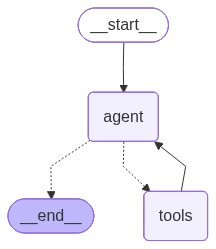

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11: Build the StateGraph
# ══════════════════════════════════════════════════════════════════════════════
# Now we assemble all the pieces into a complete graph:
#
# 1. Create the graph with our state schema
# 2. Add nodes (agent and tools)
# 3. Set the entry point
# 4. Add edges (including conditional edges)
# 5. Compile the graph
#
# After compilation, the graph is ready to run!
# ══════════════════════════════════════════════════════════════════════════════

# Create the graph with our state schema
graph_builder = StateGraph(AgentState)

# Add nodes
graph_builder.add_node("agent", agent_node)      # The reasoning node
graph_builder.add_node("tools", ToolNode(tools)) # The tool execution node (prebuilt)

# Set entry point - where the graph starts
graph_builder.set_entry_point("agent")

# Add conditional edge from agent
# This implements the ReAct loop!
graph_builder.add_conditional_edges(
    "agent",           # From node
    should_continue,   # Routing function we defined to determine if agent should continue
    {                  # Mapping of return values to nodes
        "tools": "tools",
        "__end__": END
    }
)

# After tools execute, always go back to agent
# This completes the loop: agent → tools → agent → ...
graph_builder.add_edge("tools", "agent")

# Compile the graph (no checkpointer yet)
graph = graph_builder.compile()

print("✓ Graph built and compiled!")
print("\nGraph structure:")
print("  START → agent → (tools → agent)* → END")
print("  * = repeat while agent makes tool calls")

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

---

## Part 4: Persistence and Streaming

### Persistence (Checkpointing)

Checkpointing saves the agent's state at each step. This enables:
- **Resumption**: Continue a conversation after interruption
- **Debugging**: Inspect state at any point in the conversation
- **Branching**: Try different paths from the same checkpoint

LangGraph provides `MemorySaver` for in-memory checkpointing (good for development).
For production, you'd use `SqliteSaver` or a database-backed checkpointer.

### Streaming

Streaming lets you observe the agent's reasoning in real-time:
- See tool calls as they happen
- Watch the ReAct loop unfold
- Get faster time-to-first-token

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12: Add Persistence with MemorySaver
# ══════════════════════════════════════════════════════════════════════════════
# A checkpointer saves the state after each node execution.
#
# MemorySaver stores checkpoints in memory (fast, but lost on restart).
# For production, use SqliteSaver or a database-backed checkpointer.
#
# When using a checkpointer, you must provide a "thread_id" to identify
# the conversation. This lets you have multiple concurrent conversations.
# ══════════════════════════════════════════════════════════════════════════════

# Create checkpointer
memory = MemorySaver()

# Recompile graph with checkpointer
# IMPORTANT: recursion_limit caps the number of ReAct iterations to prevent
# runaway loops and excessive API usage.
graph_with_memory = graph_builder.compile(
    checkpointer=memory,
)

# Set a conservative recursion limit when invoking.
# LangGraph counts both agent and tool-node steps, so 10 gives enough room for:
# 2 targeted searches → 1 batch classification → actions → final summary.
MAX_ITERATIONS = 10

print("✓ Graph recompiled with MemorySaver checkpointer")
print(f"✓ Max iterations: {MAX_ITERATIONS} (to limit API calls)")
print("\nCheckpointing enables:")
print("  - Resume conversations after interruption")
print("  - Inspect state at any point")
print("  - Branch conversations from checkpoints")

✓ Graph recompiled with MemorySaver checkpointer
✓ Max iterations: 10 (to limit API calls)

Checkpointing enables:
  - Resume conversations after interruption
  - Inspect state at any point
  - Branch conversations from checkpoints


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13: Streaming Demonstration
# ══════════════════════════════════════════════════════════════════════════════
# Streaming lets you watch the agent work in real-time.
#
# The .stream() method yields events as they happen:
#   - Each node execution produces an event
#   - Tool calls and results appear as they happen
#   - You can see the ReAct loop unfold step by step
#
# This is useful for:
#   - Debugging agent behavior
#   - Showing progress to users
#   - Faster perceived responsiveness
# ══════════════════════════════════════════════════════════════════════════════

def run_agent_with_streaming(query: str, thread_id: str = "demo-1"):
    """
    Run the agent with streaming output and rate limit protection.
    
    Args:
        query: The user's question or command
        thread_id: Unique identifier for this conversation
    """
    print(f"\n{'='*70}")
    print(f"🤖 Agent Query: {query}")
    print(f"⚡ Rate limit: {rate_limiter.calls_per_minute} calls/min | Max iterations: {MAX_ITERATIONS}")
    print(f"{'='*70}\n")
    
    # Configuration with thread_id for checkpointing
    # recursion_limit prevents runaway ReAct loops (each iteration = 1 API call)
    config = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": MAX_ITERATIONS
    }
    
    # Initial state follows AgentState from CELL 3.
    initial_state = {
        "messages": [HumanMessage(content=query)],
        "detected_events": [],
        "pipelines_triggered": [],
        "news_sources": NEWS_DOMAINS
    }
    
    # Stream events with error handling for rate limits
    step = 0
    try:
        for event in graph_with_memory.stream(initial_state, config):
            step += 1
            
            # Each event is a dict with node_name: output
            for node_name, output in event.items():
                print(f"\n📍 Step {step}: {node_name.upper()}")
                print("-" * 50)
                
                if "messages" in output:
                    for msg in output["messages"]:
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            print("🔧 Tool calls:")
                            for tc in msg.tool_calls:
                                print(f"   - {tc['name']}({json.dumps(tc['args'], indent=2)[:100]}...)")
                        elif hasattr(msg, 'content') and msg.content:
                            content = msg.content
                            if isinstance(content, str):
                                if len(content) > 500:
                                    print(f"💬 {content[:500]}...")
                                else:
                                    print(f"💬 {content}")
        
        print(f"\n{'='*70}")
        print(f"✅ Agent completed ({rate_limiter.call_count} total API calls this session)")
        print(f"{'='*70}")
        
    except Exception as e:
        error_msg = str(e)
        if "429" in error_msg or "RESOURCE_EXHAUSTED" in error_msg or "quota" in error_msg.lower():
            # Extract retry time if available
            import re
            retry_match = re.search(r'retry in (\d+\.?\d*)', error_msg.lower())
            retry_time = float(retry_match.group(1)) if retry_match else 60
            
            print(f"\n{'='*70}")
            print(f"⚠️  RATE LIMIT HIT after {rate_limiter.call_count} API calls")
            print(f"    Free tier: 15 RPM, 1,500 RPD for gemini-3.1-flash-lite")
            print(f"    Suggested: Wait {retry_time:.0f}s or check daily quota at:")
            print(f"    https://ai.google.dev/aistudio/apikey")
            print(f"{'='*70}")
        else:
            raise


print("✓ Streaming helper function defined")
print("\nRun: run_agent_with_streaming('your query here')")

✓ Streaming helper function defined

Run: run_agent_with_streaming('your query here')


---

## Part 5: Testing the Agent

Now let's test our agent with different scenarios:

1. **Simulated news search** — Using our mock news database
2. **Event classification** — Testing the classification tool
3. **Pipeline triggering** — Testing dry-run pipeline execution

⚠️ **Note**: The first test requires an Google API key. If you don't have one, skip to the "Testing Without API" section.

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14: Basic Agent Test
# ══════════════════════════════════════════════════════════════════════════════
# Let's test the agent with a simple query.
#
# The agent should:
# 1. Search for news about the transfer portal
# 2. Classify any events it finds
# 3. Trigger pipelines if appropriate (in dry-run mode)
# 4. Summarize what it found
#
# ⚠️ This requires Google_API_KEY to be set!
# ══════════════════════════════════════════════════════════════════════════════

if GOOGLE_API_KEY:
    run_agent_with_streaming(
        "Search for recent transfer portal news and report any player movements.",
        thread_id="test-basic-1"
    )
else:
    print("⚠️ Skipping test - GOOGLE_API_KEY not set")
    print("   Add your API key to .env and re-run the imports cell")


🤖 Agent Query: Search for recent transfer portal news and report any player movements.
⚡ Rate limit: 12 calls/min | Max iterations: 10

🔄 API call #1 (2 messages in context)

📍 Step 1: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({
  "query": "college basketball transfer portal player enters portal"
}...)
🔍 Tavily search: query='college basketball transfer portal player enters portal', depth=advanced, domains=['247sports.com', 'espn.com', 'on3.com']
✓ Found 10 results, 0 passed score filter (>= 0.5)

📍 Step 2: TOOLS
--------------------------------------------------
💬 []
🔄 API call #2 (4 messages in context)

📍 Step 3: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({
  "query": "college basketball head coach leaves resigns fired departs"
}...)
🔍 Tavily search: query='college basketball head coach leaves resigns fired departs', depth=advanced, domains=['247sports.com', 'espn.com', 'on3.com']
✓ Found 10 

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15: Test Coaching News
# ══════════════════════════════════════════════════════════════════════════════
# Test the agent's handling of coaching changes.
#
# Per our system prompt, coaching changes should be REPORTED but not
# automatically trigger pipelines (they require manual review).
# ══════════════════════════════════════════════════════════════════════════════

if GOOGLE_API_KEY:
    run_agent_with_streaming(
        "Check if there are any recent coaching changes in college basketball.",
        thread_id="test-coaching-1"
    )
else:
    print("⚠️ Skipping test - GOOGLE_API_KEY not set")


🤖 Agent Query: Check if there are any recent coaching changes in college basketball.
⚡ Rate limit: 12 calls/min | Max iterations: 10

🔄 API call #4 (2 messages in context)

📍 Step 1: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({
  "query": "college basketball head coach leaves resigns fired departs"
}...)
🔍 Tavily search: query='college basketball head coach leaves resigns fired departs', depth=advanced, domains=['247sports.com', 'espn.com', 'on3.com']
✓ Found 10 results, 0 passed score filter (>= 0.5)

📍 Step 2: TOOLS
--------------------------------------------------
💬 []
⏳ Rate limit: waiting 3.6s...
🔄 API call #5 (4 messages in context)

📍 Step 3: AGENT
--------------------------------------------------
🔧 Tool calls:
   - search_news({
  "query": "college basketball transfer portal player enters portal"
}...)
🔍 Tavily search: query='college basketball transfer portal player enters portal', depth=advanced, domains=['247sports.com', 'espn.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16: Testing Tools Directly
# ══════════════════════════════════════════════════════════════════════════════
# This tests each component without running the full agent loop.
# search_news requires TAVILY_API_KEY; classification and dry-run pipeline tests
# can be exercised independently.
# ══════════════════════════════════════════════════════════════════════════════

print("Testing tools directly")
print("="*60)

# Test 1: Search news
print("\n1. Testing search_news:")
news_result = search_news.invoke({
    "query": "college basketball transfer portal player enters portal commits",
    "max_results": 5
})
news_data = json.loads(news_result)
print(f"   Found {len(news_data)} articles")
for article in news_data:
    print(f"   - {article['title'][:50]}...")

# Test 2: Batch classify events
print("\n2. Testing classify_events_batch:")
batch_classification = classify_events_batch.invoke({
    "search_results_json": news_result,
    "max_articles": 5
})
batch_data = json.loads(batch_classification)
print(f"   Classified {batch_data['articles_classified']} articles")
print(f"   Target events found: {batch_data['target_events_found']}")
for event in batch_data["target_events"]:
    print(f"   → {event['event_type']} | {event['title'][:45]}... | confidence={event['confidence']}")

# Test 3: Trigger pipeline (dry run)
print("\n3. Testing trigger_pipeline (dry run):")
trigger_result = trigger_pipeline.invoke({
    "pipeline_name": "ingest_transfers",
    "reason": "Test trigger from notebook",
    "dry_run": True
})
trigger_data = json.loads(trigger_result)
print(f"   Pipeline: {trigger_data['pipeline']}")
print(f"   Command: {trigger_data['command']}")
print(f"   Dry run: {trigger_data['dry_run']}")

print("\n✓ All tools working correctly!")

Testing tools directly

1. Testing search_news:
🔍 Tavily search: query='college basketball transfer portal player enters portal commits', depth=advanced, domains=['247sports.com', 'espn.com', 'on3.com']
✓ Found 5 results, 0 passed score filter (>= 0.5)
   Found 0 articles

2. Testing classify_events_batch:
   Classified 0 articles
   Target events found: 0

3. Testing trigger_pipeline (dry run):
🔍 [DRY RUN] Would execute: uv run python C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone\scripts\ingest_transfers_247sports.py --seasons 2026 --dry-run
   Pipeline: ingest_transfers
   Command: uv run python C:\Users\nhanj\Desktop\MIDS\Summer 2026\W210\MIDS210-Capstone\scripts\ingest_transfers_247sports.py --seasons 2026 --dry-run
   Dry run: True

✓ All tools working correctly!


---

## Educational Summary: How This Agent Works

### Key Architectural Changes Made

**1. TypedDict Schemas with Literal Types (CELL 3)**

We enhanced the state management with type-safe event classification:

```python
# Literal types enable type-safe conditional routing
EventType = Literal["player_enters_portal", "coach_leaves", "unknown"]

class DetectedEvent(TypedDict):
    event_type: EventType  # The LLM uses this to decide which tool to call
    player_name: Optional[str]
    coach_name: Optional[str]
    school_from: Optional[str]
    confidence: float
    source_url: Optional[str]
```

**Why Literal types?**
- IDE autocomplete for valid event types
- Compile-time validation catches typos
- Clear documentation of valid categories
- Foundation for conditional routing logic

**2. Tavily Search Integration (CELL 4) — Python Client**

Uses the Tavily Python client (production best practice) instead of CLI:

```python
from tavily import TavilyClient

# Reads TAVILY_API_KEY from environment automatically
tavily_client = TavilyClient()

response = tavily_client.search(
    query="college basketball transfer portal",
    topic="news",
    search_depth="advanced",
    time_range="week",
    include_domains=["247sports.com", "espn.com", "on3.com"],
    max_results=10,
    chunks_per_source=3
)

# Best practice: Score-based post-filtering
high_quality = [r for r in response["results"] if r["score"] >= 0.5]
```

**Why Python client over CLI?**
- Reads `TAVILY_API_KEY` from `.env` automatically (no `tvly login` needed)
- Native Python — no subprocess overhead
- Full parameter access (`chunks_per_source`, async support, etc.)
- Better error handling with typed exceptions

**Historical evaluation placeholders:**
```python
# Uncomment in CELL 4 to test agent on historical data
# START_DATE = "2026-03-01"
# END_DATE = "2026-03-31"
```

**3. Conditional Routing Pattern (CELL 11)**

The ReAct loop uses two-level routing:

```
Level 1: should_continue()
    agent message → has tool_calls? → YES → tools node
                                    → NO  → END

Level 2: LLM-driven tool selection
    Based on event_type from classify_event:
    • "player_enters_portal" → transfer_player tool
    • "coach_leaves" → coach_departure tool
    • "unknown" → skip
```

**Why LLM-driven routing?**
- Flexibility: Handles edge cases the LLM understands from context
- Multi-tool: Can call multiple tools in sequence
- Context-aware: Sees full conversation history

### Quick Start

1. Add API keys to `.env`:
   ```
   GOOGLE_API_KEY=your_key_here
   TAVILY_API_KEY=your_key_here
   ```

2. Install dependencies (if not already installed):
   ```bash
   uv pip install -r notebooks/requirements-notebooks.txt
   ```

3. Run the test cells to see the agent in action!

### Evaluation Strategy

To test agent performance on historical data:
1. Uncomment `START_DATE` and `END_DATE` in CELL 4
2. Set to a date range with known transfer portal events
3. Run the agent and compare detected events to ground truth
4. Calculate precision (correct detections / total detections) and recall (correct detections / total actual events)

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 17: Checkpoint Inspection
# ══════════════════════════════════════════════════════════════════════════════
# After running the agent, we can inspect the saved checkpoints.
# This shows how persistence works - you can see the state at each step.
# ══════════════════════════════════════════════════════════════════════════════

def inspect_checkpoints(thread_id: str):
    """Inspect the checkpoints for a given thread."""
    config = {"configurable": {"thread_id": thread_id}}
    
    # Get the current state
    state = graph_with_memory.get_state(config)
    
    if state.values:
        print(f"\n📊 State for thread '{thread_id}':")
        print("-" * 50)
        print(f"Messages: {len(state.values.get('messages', []))}")
        print(f"Detected events: {len(state.values.get('detected_events', []))}")
        print(f"Pipelines triggered: {state.values.get('pipelines_triggered', [])}")
        print(f"News sources: {state.values.get('news_sources', [])}")
        
        # Show last few messages
        messages = state.values.get('messages', [])
        if messages:
            print(f"\nLast {min(3, len(messages))} messages:")
            for msg in messages[-3:]:
                msg_type = type(msg).__name__
                content = getattr(msg, 'content', '')
                if isinstance(content, str) and len(content) > 100:
                    content = content[:100] + "..."
                print(f"  [{msg_type}] {content}")
    else:
        print(f"No state found for thread '{thread_id}'")


# Inspect the test thread (if it exists)
inspect_checkpoints("test-basic-1")


📊 State for thread 'test-basic-1':
--------------------------------------------------
Messages: 6
Detected events: 0
Pipelines triggered: []
News sources: ['247sports.com', 'espn.com', 'on3.com']

Last 3 messages:
  [AIMessage] []
  [ToolMessage] []
  [AIMessage] [{'type': 'text', 'text': 'No recent college basketball transfer portal movements or coaching changes were found in the latest news reports. I will continue to monitor these sources for updates.', 'extras': {'signature': 'EjQKMgEMOdbH3/gjqRbyisV2SPOqr54KH/j4UaQ0FGXMqCWqBrjEZ3PLiVaHeRFuxWAG0kdf'}}]


---

## Part 6: Production Considerations

This notebook demonstrates the fundamentals. For production use, consider:

### Real News Sources
The notebook now uses **Tavily API via the Python client** for web search. For production hardening, consider:
- **Targeted query templates**: Separate transfer/player-movement and coach-departure searches
- **Direct RSS feeds**: 247Sports, ESPN, On3 RSS feeds for lower-latency source monitoring
- **Source caching**: Store Tavily responses during evals to avoid repeated API usage
- **Web scraping**: Custom scraper for specific sites only when allowed by robots.txt and terms

### Persistent Storage
Replace `MemorySaver` with:
- `SqliteSaver`: Persistent file-based storage
- PostgreSQL checkpointer: Use your existing DB
- Redis checkpointer: For distributed systems

### Scheduling
For continuous monitoring:
- GitHub Actions cron job (matches your existing approach)
- Celery beat for more complex scheduling
- AWS Lambda + EventBridge for serverless

### Error Handling
Add:
- Retry logic for API failures
- Dead letter queue for failed events
- Alerting for critical errors

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18: Production-Ready Configuration
# ══════════════════════════════════════════════════════════════════════════════
# Example of how you might configure the agent for production.
# This shows the pattern - actual implementation would go in src/portalpoint/
# ══════════════════════════════════════════════════════════════════════════════

# Production configuration (example)
PRODUCTION_CONFIG = {
    "news_sources": {
        "247sports": {
            "enabled": True,
            "priority": 1,
            "url_pattern": "https://247sports.com/season/{season}-basketball/transferportal/"
        },
        "espn": {
            "enabled": True,
            "priority": 2,
            "rss_feed": "https://www.espn.com/espn/rss/ncb/news"
        },
        "on3": {
            "enabled": True,
            "priority": 3,
            "url_pattern": "https://www.on3.com/transfer-portal/basketball/"
        }
    },
    "pipelines": {
        "player_enters_portal": "ingest_transfers",
        "coach_leaves": None,  # Manual review required
    },
    "schedule": {
        "frequency": "hourly",
        "active_hours": "06:00-22:00 ET",
        "peak_hours": "12:00-18:00 ET"  # More frequent during peak
    },
    "llm": {
        "model": "gemini-3.1-flash-lite",
        "temperature": 0,
        "max_tokens": 4096
    }
}

print("Production configuration example:")
print(json.dumps(PRODUCTION_CONFIG, indent=2))

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 19: Summary and Next Steps
# ══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                           🎉 Congratulations! 🎉                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

You've built your first AI agent using the ReAct framework!

What you learned:
─────────────────
✓ State Management   - TypedDict defines what the agent remembers
✓ Tools              - Functions the agent can call (@tool decorator)
✓ Graph Construction - StateGraph connects nodes with edges
✓ Conditional Routing - should_continue decides the next step
✓ Persistence        - MemorySaver enables checkpointing
✓ Streaming          - Real-time observation of agent reasoning

Key files created:
──────────────────
• notebooks/agents/news_monitor_agent.ipynb  (this notebook)
• notebooks/requirements-notebooks.txt       (updated dependencies)
• .env.example                               (API key placeholder)

Next steps:
───────────
1. Add your GOOGLE_API_KEY to .env
2. Run the test cells to see the agent in action
3. Customize news sources and event types
4. Move to production with real news APIs

Resources:
──────────
• LangGraph docs: https://langchain-ai.github.io/langgraph/
• LangChain docs: https://python.langchain.com/
• GOOGLE docs: https://docs.GOOGLE.com/
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                           🎉 Congratulations! 🎉                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

You've built your first AI agent using the ReAct framework!

What you learned:
─────────────────
✓ State Management   - TypedDict defines what the agent remembers
✓ Tools              - Functions the agent can call (@tool decorator)
✓ Graph Construction - StateGraph connects nodes with edges
✓ Conditional Routing - should_continue decides the next step
✓ Persistence        - MemorySaver enables checkpointing
✓ Streaming          - Real-time observation of agent reasoning

Key files created:
──────────────────
• notebooks/agents/news_monitor_agent.ipynb  (this notebook)
• notebooks/requirements-notebooks.txt       (updated dependencies)
• .env.example                               (API key placeholder)

Next steps:
───────────
1. Add your GOOGLE_AP

---

## Part 7: Evals — Benchmarking Agent Classification Performance

This section wires the agent against **historical news** to benchmark how well each classifier detects real-world events.

### Evaluation Approach

| Step | Description |
|------|-------------|
| **Ground Truth** | Known historical events (coach firings, player portal entries) with date ranges |
| **Historic Search** | Tavily search filtered to the event's specific date range |
| **Classify** | Run both regex and LLM classifiers on retrieved articles |
| **Score** | Compare detected events to expected event type |

### Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Detection Rate** | detected / total scenarios | Did we find the right event type at all? (recall proxy) |
| **Precision** | correct_type / all_detected | Of detected events, how many match the expected type? |
| **Disagreement Rate** | regex ≠ llm / total | How often do the two classifiers give different answers? |

### When to Prefer LLM vs Regex

- **LLM classifier**: higher precision on ambiguous/implicit headlines, context-aware entity extraction
- **Regex classifier**: deterministic (same result every run), zero extra API cost, better for evals needing reproducibility

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# EVAL CELL 1: Ground Truth Dataset
# ══════════════════════════════════════════════════════════════════════════════
# Known historical college basketball events with targeted Tavily search queries
# and date ranges to retrieve articles from that specific period.
#
# Sources: verified from public record (ESPN, 247Sports, AP Sports, On3)
# Each entry has: event_type we expect to detect, a Tavily query, and date range.
# ══════════════════════════════════════════════════════════════════════════════

EVAL_GROUND_TRUTH = [
    # ── Coach Departure Events ─────────────────────────────────────────────────
    {
        "id": "calipari_leaves_kentucky_2024",
        "event_type": "coach_leaves",
        "coach_name": "John Calipari",
        "player_name": None,
        "school_from": "Kentucky",
        "search_query": "John Calipari leaves Kentucky head coach Arkansas 2024",
        "date_start": "2024-03-25",
        "date_end": "2024-04-05",
        "notes": "Calipari departed Kentucky after 15 seasons for Arkansas, announced late March 2024",
        "expected_keywords": ["Calipari", "Kentucky", "Arkansas", "leaves", "departure"],
    },
    {
        "id": "juwan_howard_fired_michigan_2024",
        "event_type": "coach_leaves",
        "coach_name": "Juwan Howard",
        "player_name": None,
        "school_from": "Michigan",
        "search_query": "Juwan Howard fired Michigan basketball head coach February 2024",
        "date_start": "2024-02-05",
        "date_end": "2024-02-20",
        "notes": "Howard was fired mid-season February 2024 following an on-court altercation",
        "expected_keywords": ["Howard", "Michigan", "fired", "dismissed"],
    },
    {
        "id": "dusty_may_leaves_fau_2024",
        "event_type": "coach_leaves",
        "coach_name": "Dusty May",
        "player_name": None,
        "school_from": "Florida Atlantic",
        "search_query": "Dusty May Florida Atlantic Michigan basketball head coach hire 2024",
        "date_start": "2024-03-15",
        "date_end": "2024-03-31",
        "notes": "Dusty May left FAU to take the Michigan head coaching job, March 2024",
        "expected_keywords": ["Dusty May", "Florida Atlantic", "Michigan"],
    },
    {
        "id": "coach_departures_postseason_2025",
        "event_type": "coach_leaves",
        "coach_name": None,
        "player_name": None,
        "school_from": None,
        "search_query": "college basketball head coach fired resigned leaves departs program March April 2025",
        "date_start": "2025-03-15",
        "date_end": "2025-04-15",
        "notes": "End-of-season 2024-25 coaching changes — multiple programs expected",
        "expected_keywords": ["coach", "fired", "resigned", "leaves", "departs"],
    },
    # ── Transfer Portal Events ──────────────────────────────────────────────────
    {
        "id": "portal_window_spring_2025",
        "event_type": "player_enters_portal",
        "coach_name": None,
        "player_name": None,
        "school_from": None,
        "search_query": "college basketball player enters NCAA transfer portal spring 2025 commits",
        "date_start": "2025-04-01",
        "date_end": "2025-04-20",
        "notes": "Spring 2025 portal window — high-profile player movements expected",
        "expected_keywords": ["transfer portal", "portal", "enters", "declared"],
    },
    {
        "id": "portal_window_dec_2024",
        "event_type": "player_enters_portal",
        "coach_name": None,
        "player_name": None,
        "school_from": None,
        "search_query": "college basketball player enters transfer portal December 2024",
        "date_start": "2024-12-10",
        "date_end": "2024-12-31",
        "notes": "December 2024 in-season portal window",
        "expected_keywords": ["transfer portal", "portal", "enters"],
    },
]

print(f"✓ Ground truth: {len(EVAL_GROUND_TRUTH)} test scenarios")
print()
for entry in EVAL_GROUND_TRUTH:
    entity = entry.get("coach_name") or entry.get("player_name") or "(multiple)"
    print(f"  [{entry['event_type']:22s}] {entry['id']}")
    print(f"    Entity:  {entity}")
    print(f"    Period:  {entry['date_start']} → {entry['date_end']}")
    print()

✓ Ground truth: 6 test scenarios

  [coach_leaves          ] calipari_leaves_kentucky_2024
    Entity:  John Calipari
    Period:  2024-03-25 → 2024-04-05

  [coach_leaves          ] juwan_howard_fired_michigan_2024
    Entity:  Juwan Howard
    Period:  2024-02-05 → 2024-02-20

  [coach_leaves          ] dusty_may_leaves_fau_2024
    Entity:  Dusty May
    Period:  2024-03-15 → 2024-03-31

  [coach_leaves          ] coach_departures_postseason_2025
    Entity:  (multiple)
    Period:  2025-03-15 → 2025-04-15

  [player_enters_portal  ] portal_window_spring_2025
    Entity:  (multiple)
    Period:  2025-04-01 → 2025-04-20

  [player_enters_portal  ] portal_window_dec_2024
    Entity:  (multiple)
    Period:  2024-12-10 → 2024-12-31



In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# EVAL CELL 2: Historic News Search + Dual-Classifier Helper
# ══════════════════════════════════════════════════════════════════════════════
# search_historic_news: Tavily search with start_date/end_date to retrieve
#   articles from a specific historical period. Lower score threshold (0.3)
#   compared to live search (0.5) to capture more potentially relevant articles.
#
# classify_articles_both: Run regex AND LLM classifiers on the same article
#   list so we can compare results side by side for each eval scenario.
# ══════════════════════════════════════════════════════════════════════════════

def search_historic_news(
    query: str,
    start_date: str,
    end_date: str,
    max_results: int = 10,
    include_domains: list = None,
) -> list:
    """
    Search Tavily for news articles within a specific date range.

    Args:
        query: Search query
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
        max_results: Max results to return (capped at 20)
        include_domains: Domains to search (defaults to NEWS_DOMAINS)

    Returns:
        List of article dicts: title, url, content, score, published_date
    """
    if tavily_client is None:
        print("  ⚠️ Tavily client unavailable — add TAVILY_API_KEY to .env")
        return []

    domains = include_domains or NEWS_DOMAINS

    try:
        print(f"  🔍 Searching: '{query[:55]}...' | {start_date} → {end_date}")
        response = tavily_client.search(
            query=query,
            topic="news",
            search_depth="advanced",
            max_results=min(max_results, 20),
            start_date=start_date,
            end_date=end_date,
            include_domains=domains,
            chunks_per_source=3,
        )
        raw = response.get("results", [])
        # Use a lower score threshold for evals to avoid missing relevant articles
        filtered = sorted(
            [r for r in raw if r.get("score", 0) >= 0.3],
            key=lambda x: x.get("score", 0),
            reverse=True,
        )
        articles = [
            {
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "content": r.get("content", ""),
                "score": round(r.get("score", 0), 3),
                "published_date": r.get("published_date", "Unknown"),
            }
            for r in filtered
        ]
        print(f"  ✓ {len(raw)} raw results → {len(articles)} above 0.3 score threshold")
        return articles

    except Exception as e:
        print(f"  ✗ Search error: {type(e).__name__}: {str(e)[:80]}")
        return []


def classify_articles_both(articles: list) -> dict:
    """
    Run regex AND LLM classifiers on the same article list.

    Returns:
        dict with 'regex' and 'llm' keys, each containing classify_events_batch output
    """
    if not articles:
        empty = {"articles_classified": 0, "target_events_found": 0, "classifications": [], "target_events": []}
        return {"regex": empty, "llm": empty}

    articles_json = json.dumps(articles)

    # Regex classifier — always available, deterministic
    regex_result = json.loads(
        classify_events_batch.invoke({"search_results_json": articles_json, "max_articles": len(articles)})
    )

    # LLM classifier — requires GOOGLE_API_KEY
    if GOOGLE_API_KEY:
        llm_result = json.loads(
            classify_events_batch_llm.invoke({"search_results_json": articles_json, "max_articles": len(articles)})
        )
    else:
        llm_result = {
            "articles_classified": 0,
            "target_events_found": 0,
            "classifications": [],
            "target_events": [],
            "error": "GOOGLE_API_KEY not set",
        }

    return {"regex": regex_result, "llm": llm_result}


print("✓ Historic eval helpers defined")
print("  search_historic_news(query, start_date, end_date) — Tavily with date filter")
print("  classify_articles_both(articles)                  — regex + LLM side-by-side")

✓ Historic eval helpers defined
  search_historic_news(query, start_date, end_date) — Tavily with date filter
  classify_articles_both(articles)                  — regex + LLM side-by-side


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# EVAL CELL 3: Per-Scenario Evaluation Runner
# ══════════════════════════════════════════════════════════════════════════════
# evaluate_scenario: Searches historic Tavily results for one ground truth entry,
#   runs both classifiers, and returns structured metrics.
#
# Metrics computed per scenario:
#   detected      — Did any target event match the expected type?
#   true_positives  — Target events whose event_type == expected_type
#   false_positives — Target events whose event_type != expected_type
#   precision       — TP / (TP + FP)   (quality of detections)
# ══════════════════════════════════════════════════════════════════════════════

def _compute_metrics(clf_result: dict, expected_type: str) -> dict:
    """Compute detection metrics for one classifier's output."""
    total = clf_result.get("articles_classified", 0)
    targets = clf_result.get("target_events", [])
    tp = sum(1 for t in targets if t.get("event_type") == expected_type)
    fp = len(targets) - tp
    precision = round(tp / len(targets), 3) if targets else 0.0
    return {
        "detected": tp > 0,
        "true_positives": tp,
        "false_positives": fp,
        "target_count": len(targets),
        "total_classified": total,
        "precision": precision,
        "target_events": targets,
    }


def evaluate_scenario(scenario: dict, verbose: bool = True) -> dict:
    """
    Evaluate one ground truth scenario with both classifiers.

    Args:
        scenario: Entry from EVAL_GROUND_TRUTH
        verbose: Print per-scenario details

    Returns:
        dict with scenario_id, articles_found, and per-classifier metrics
    """
    if verbose:
        print(f"\n{'─' * 65}")
        print(f"  Scenario: {scenario['id']}")
        print(f"  Expected: {scenario['event_type']}")
        print(f"  Period:   {scenario['date_start']} → {scenario['date_end']}")
        if scenario.get("notes"):
            print(f"  Notes:    {scenario['notes']}")

    articles = search_historic_news(
        query=scenario["search_query"],
        start_date=scenario["date_start"],
        end_date=scenario["date_end"],
        max_results=8,
    )

    if not articles:
        if verbose:
            print("  ⚠️  No articles found — skipping (Tavily may not have indexed this period)")
        empty_m = {"detected": False, "true_positives": 0, "false_positives": 0,
                   "target_count": 0, "total_classified": 0, "precision": 0.0, "target_events": []}
        return {
            "scenario_id": scenario["id"],
            "expected_type": scenario["event_type"],
            "articles_found": 0,
            "regex": empty_m,
            "llm": empty_m,
            "skipped": True,
        }

    results = classify_articles_both(articles)
    regex_m = _compute_metrics(results["regex"], scenario["event_type"])
    llm_m   = _compute_metrics(results["llm"],   scenario["event_type"])

    if verbose:
        r_det = "✅" if regex_m["detected"] else "❌"
        l_det = "✅" if llm_m["detected"]   else "❌"
        print(f"  Articles: {len(articles)} found")
        print(f"  Regex  {r_det}  targets={regex_m['target_count']}  TP={regex_m['true_positives']}  FP={regex_m['false_positives']}  precision={regex_m['precision']:.2f}")
        print(f"  LLM    {l_det}  targets={llm_m['target_count']}   TP={llm_m['true_positives']}  FP={llm_m['false_positives']}  precision={llm_m['precision']:.2f}")

        # Show what was detected
        for clf_name, m in [("Regex", regex_m), ("LLM", llm_m)]:
            for ev in m["target_events"]:
                correct = ev.get("event_type") == scenario["event_type"]
                mark = "✅" if correct else "❌"
                entity = ev.get("player_name") or ev.get("coach_name") or "?"
                reason = f" | {ev.get('reasoning', '')[:50]}" if clf_name == "LLM" and ev.get("reasoning") else ""
                print(f"    {clf_name} {mark}: [{ev['event_type']}] {entity} — {ev.get('title', '')[:50]}...{reason}")

    return {
        "scenario_id": scenario["id"],
        "expected_type": scenario["event_type"],
        "articles_found": len(articles),
        "regex": regex_m,
        "llm": llm_m,
        "skipped": False,
    }


print("✓ evaluate_scenario() defined")
print("  Runs one ground truth scenario through both classifiers")
print("\nNext: run EVAL CELL 4 to benchmark all scenarios and see the comparison table.")

✓ evaluate_scenario() defined
  Runs one ground truth scenario through both classifiers

Next: run EVAL CELL 4 to benchmark all scenarios and see the comparison table.


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# EVAL CELL 4: Run Evaluations — Regex vs LLM Benchmark
# ══════════════════════════════════════════════════════════════════════════════
# Runs ground truth scenarios through both classifiers and prints a summary table.
#
# ⚠️  Each scenario makes Tavily + Gemini API calls.
#     Adjust EVAL_SCENARIOS_TO_RUN to control how many scenarios to run.
#
#     EVAL_GROUND_TRUTH[:2]  → run first 2 scenarios (cheapest, good for a quick test)
#     EVAL_GROUND_TRUTH[:4]  → run first 4 scenarios
#     EVAL_GROUND_TRUTH      → run all scenarios
# ══════════════════════════════════════════════════════════════════════════════

EVAL_SCENARIOS_TO_RUN = EVAL_GROUND_TRUTH[:3]  # ← adjust slice here

print("=" * 70)
print("EVAL: Regex vs LLM Classifier on Historical College Basketball News")
print("=" * 70)
print(f"Running {len(EVAL_SCENARIOS_TO_RUN)} of {len(EVAL_GROUND_TRUTH)} ground truth scenarios...\n")

eval_results = []
for scenario in EVAL_SCENARIOS_TO_RUN:
    result = evaluate_scenario(scenario, verbose=True)
    eval_results.append(result)
    time.sleep(3)  # Brief pause between scenarios to respect API rate limits

# ─────────────────────────────────────────────────────────────────────────────
# Summary Table
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n\n{'=' * 70}")
print("SUMMARY TABLE")
print(f"{'=' * 70}")
header = f"{'Scenario':<35} {'Expected':>16} {'Arts':>5} {'R-Det':>6} {'L-Det':>6} {'R-Prec':>7} {'L-Prec':>7}"
print(header)
print("-" * len(header))

regex_dets, llm_dets = 0, 0
regex_precisions, llm_precisions = [], []

for r in eval_results:
    if r.get("skipped"):
        continue
    r_det = "✅" if r["regex"]["detected"] else "❌"
    l_det = "✅" if r["llm"]["detected"]   else "❌"
    r_p   = r["regex"]["precision"]
    l_p   = r["llm"]["precision"]

    if r["regex"]["detected"]:
        regex_dets += 1
    if r["llm"]["detected"]:
        llm_dets += 1
    regex_precisions.append(r_p)
    llm_precisions.append(l_p)

    row = (
        f"{r['scenario_id'][:34]:<35} "
        f"{r['expected_type'][:15]:>16} "
        f"{r['articles_found']:>5} "
        f"{r_det:>6} "
        f"{l_det:>6} "
        f"{r_p:>7.2f} "
        f"{l_p:>7.2f}"
    )
    print(row)

n_run = len([r for r in eval_results if not r.get("skipped")])
n_skip = len([r for r in eval_results if r.get("skipped")])
print("-" * len(header))

regex_dr = regex_dets / n_run if n_run else 0
llm_dr   = llm_dets   / n_run if n_run else 0
regex_ap  = sum(regex_precisions) / len(regex_precisions) if regex_precisions else 0
llm_ap    = sum(llm_precisions)   / len(llm_precisions)   if llm_precisions   else 0

print(f"\n{'AGGREGATE METRICS':}")
print(f"  Scenarios run:       {n_run}  (skipped: {n_skip})")
print()
print(f"  {'Metric':<30} {'Regex':>10}  {'LLM':>10}")
print(f"  {'-'*52}")
print(f"  {'Detection rate (recall proxy)':<30} {regex_dr:>10.1%}  {llm_dr:>10.1%}")
print(f"  {'Avg precision':<30} {regex_ap:>10.2f}  {llm_ap:>10.2f}")
print(f"  {'Detections':<30} {regex_dets:>10}  {llm_dets:>10}")
print()

# ── Disagreement Summary ─────────────────────────────────────────────────────
disagreement_count = 0
for r in eval_results:
    if r.get("skipped"):
        continue
    r_detected = r["regex"]["detected"]
    l_detected = r["llm"]["detected"]
    r_prec = r["regex"]["precision"]
    l_prec = r["llm"]["precision"]
    if r_detected != l_detected or abs(r_prec - l_prec) > 0.2:
        if disagreement_count == 0:
            print("NOTABLE DISAGREEMENTS (detection or precision differs significantly):")
            print("-" * 60)
        disagreement_count += 1
        print(f"  {r['scenario_id']}")
        print(f"    Regex: detected={r_detected}, precision={r_prec:.2f}")
        print(f"    LLM:   detected={l_detected}, precision={l_prec:.2f}")

if disagreement_count == 0:
    print("  ✓ Both classifiers agreed on all evaluated scenarios")

print(f"\n{'─' * 70}")
print("INTERPRETATION GUIDE:")
print("  Detection rate: higher is better (did we find the event?)")
print("  Precision:      higher is better (did we avoid false alarms?)")
print("  LLM expected to win on ambiguous/implicit headlines")
print("  Regex expected to win on exactly-worded portal/firing news")
print(f"{'─' * 70}")

EVAL_RESULTS_CACHE = eval_results
print(f"\n✓ Results stored in EVAL_RESULTS_CACHE ({len(eval_results)} entries)")

EVAL: Regex vs LLM Classifier on Historical College Basketball News
Running 3 of 6 ground truth scenarios...


─────────────────────────────────────────────────────────────────
  Scenario: calipari_leaves_kentucky_2024
  Expected: coach_leaves
  Period:   2024-03-25 → 2024-04-05
  Notes:    Calipari departed Kentucky after 15 seasons for Arkansas, announced late March 2024
  🔍 Searching: 'John Calipari leaves Kentucky head coach Arkansas 2024...' | 2024-03-25 → 2024-04-05
  ✓ 8 raw results → 1 above 0.3 score threshold
  Articles: 1 found
  Regex  ✅  targets=1  TP=1  FP=0  precision=1.00
  LLM    ❌  targets=0   TP=0  FP=0  precision=0.00
    Regex ✅: [coach_leaves] ? — John Calipari to return as Kentucky men's basketba...

─────────────────────────────────────────────────────────────────
  Scenario: juwan_howard_fired_michigan_2024
  Expected: coach_leaves
  Period:   2024-02-05 → 2024-02-20
  Notes:    Howard was fired mid-season February 2024 following an on-court altercation
  🔍 Sea

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# EVAL CELL 5: Drill-Down — Article-Level Detail for a Single Scenario
# ══════════════════════════════════════════════════════════════════════════════
# After running the benchmark, use this cell to inspect exactly which articles
# were found for a specific scenario and how each classifier labeled them.
#
# Change DRILL_DOWN_SCENARIO_ID to any id from EVAL_GROUND_TRUTH.
# ══════════════════════════════════════════════════════════════════════════════

DRILL_DOWN_SCENARIO_ID = "calipari_leaves_kentucky_2024"  # ← change to inspect another scenario

scenario = next(
    (s for s in EVAL_GROUND_TRUTH if s["id"] == DRILL_DOWN_SCENARIO_ID), None
)
if scenario is None:
    print(f"Scenario '{DRILL_DOWN_SCENARIO_ID}' not found in EVAL_GROUND_TRUTH")
else:
    print(f"DRILL-DOWN: {scenario['id']}")
    print(f"Expected:   {scenario['event_type']}")
    print(f"Period:     {scenario['date_start']} → {scenario['date_end']}")
    print("=" * 70)

    articles = search_historic_news(
        query=scenario["search_query"],
        start_date=scenario["date_start"],
        end_date=scenario["date_end"],
        max_results=10,
    )

    if not articles:
        print("No articles found. Try broadening the date range or adjusting the query.")
    else:
        print(f"\nFound {len(articles)} articles. Running both classifiers...\n")
        results = classify_articles_both(articles)

        for i, article in enumerate(articles):
            r_clf = results["regex"]["classifications"][i] if i < len(results["regex"]["classifications"]) else {}
            l_clf = results["llm"]["classifications"][i]   if i < len(results["llm"]["classifications"])   else {}

            r_type = r_clf.get("event_type", "?")
            l_type = l_clf.get("event_type", "?")
            r_conf = r_clf.get("confidence", 0)
            l_conf = l_clf.get("confidence", 0)
            agree  = "✅ agree" if r_type == l_type else "⚠️  DIFFER"

            print(f"Article {i+1}: {agree}")
            print(f"  Title:     {article['title'][:70]}")
            print(f"  Published: {article.get('published_date', 'Unknown')}  |  Score: {article['score']:.3f}")
            print(f"  Regex:     {r_type:25s} conf={r_conf:.2f}")
            print(f"  LLM:       {l_type:25s} conf={l_conf:.2f}")
            if l_clf.get("reasoning"):
                print(f"  Reasoning: {l_clf['reasoning'][:80]}")
            if l_clf.get("coach_name"):
                print(f"  Coach:     {l_clf['coach_name']} | from: {l_clf.get('school_from', '?')}")
            if l_clf.get("player_name"):
                print(f"  Player:    {l_clf['player_name']} | from: {l_clf.get('school_from', '?')}")
            print()

DRILL-DOWN: calipari_leaves_kentucky_2024
Expected:   coach_leaves
Period:     2024-03-25 → 2024-04-05
  🔍 Searching: 'John Calipari leaves Kentucky head coach Arkansas 2024...' | 2024-03-25 → 2024-04-05
  ✓ 8 raw results → 1 above 0.3 score threshold

Found 1 articles. Running both classifiers...

Article 1: ⚠️  DIFFER
  Title:     John Calipari to return as Kentucky men's basketball coach - ESPN
  Published: Wed, 27 Mar 2024 04:36:00 GMT  |  Score: 0.732
  Regex:     coach_leaves              conf=0.85
  LLM:       unknown                   conf=1.00
  Reasoning: The article explicitly states that John Calipari is returning as the head coach 
  Coach:     John Calipari | from: None

